# 02 — Forward Process

The forward process gradually destroys structure in an image by adding Gaussian noise over $T$ timesteps. By the end, the image is indistinguishable from pure noise.

In this notebook you will:
- Implement two noise schedules (linear and cosine)
- Derive and implement the closed-form forward jump — skip directly to any noise level in one step
- Visualise how MNIST digits degrade across timesteps

**Time:** ~30 minutes · **Requires:** `01_jax_basics.ipynb`

In [ ]:
# @title Setup — run this cell first (Colab only)
# !git clone https://github.com/maigimenez/let-it-rip
# %cd let-it-rip
# !pip install -q -e "."

In [ ]:
import jax
import jax.numpy as jnp
import jax.random as jr
import numpy as np
import plotly.graph_objects as go
from datasets import load_dataset
from jaxtyping import Array, Float
from plotly.subplots import make_subplots

print(f"JAX {jax.__version__} · backend: {jax.default_backend()}")

---
## How diffusion models work

A diffusion model has two processes that are mirror images of each other:

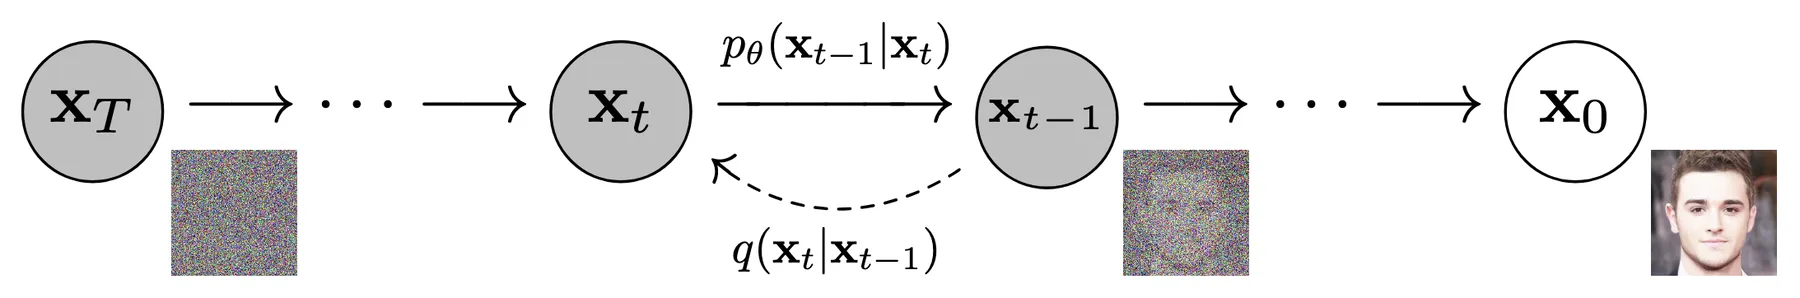

*The noising (forward) and denoising (reverse) process in DDPM. Source: Yang (2024), ["Discrete Diffusion Models"](https://blog.yanlincs.com/ml-tech/discrete-diffusion/)*

```
FORWARD  x₀ ──noise──▶ x₁ ──noise──▶ x₂ ── ··· ──▶ x_T ≈ 𝒩(0, I)
         clean image                                  pure noise

REVERSE  x_T ◀──denoise── x_{T-1} ◀── ··· ◀──denoise── x₁ ◀── x₀
         pure noise                                       generated image
```

**Forward process** (this notebook): a fixed process. At each of the $T$ steps we add a small amount of Gaussian noise. After $T$ steps the image is indistinguishable from pure noise. No learning involved.

**Reverse process** (notebooks 03–05): a learned neural network. Given a noisy image $x_t$ and the timestep $t$, the network predicts the noise that was added. Running it $T$ times starting from pure noise $x_T \sim \mathcal{N}(0, I)$ generates a new image from scratch.

**Training objective** — at each step:
1. Sample a clean image $x_0$ from the dataset
2. Pick a random timestep $t$ and noise $\varepsilon \sim \mathcal{N}(0, I)$
3. Corrupt: compute $x_t$ from $x_0$ in one shot using the closed-form formula you'll derive below
4. Predict: train the network to recover $\varepsilon$ from $(x_t, t)$, minimising $\|\varepsilon - \hat\varepsilon_\theta(x_t, t)\|^2$


---
## 1 — The forward process

In notebook 01 you implemented **lerp** — blending two vectors with a scalar $t \in [0,1]$. The forward diffusion process is very similar but in this case at each timestep we blend the previous image with fresh Gaussian noise.

Formally, the forward process is a Markov chain that produces progressively noisier versions $x_1, x_2, \ldots, x_T$ of a clean image $x_0$:

$$q(x_t \mid x_{t-1}) = \mathcal{N}\!\left(x_t;\; \sqrt{1 - \beta_t}\, x_{t-1},\; \beta_t I\right)$$

Each step scales the previous image by $\sqrt{1-\beta_t}$ (pushing it toward zero) and adds Gaussian noise with variance $\beta_t$. The scalars $\{\beta_t\}_{t=1}^{T}$ form the **noise schedule** — the key design choice that controls how quickly information is destroyed.

Let's first load some real images to make this concrete.

Gaussian noise is random noise where the values follow a normal (Gaussian) distribution defined by mean μ and standard deviation σ. We normally use **standard Gaussian noise**: $\mathcal{N}(0, 1)$, meaning zero mean and unit variance.[^1]

[^1]: Ho, J., Jain, A., & Abbeel, P. (2020). Denoising Diffusion Probabilistic Models. *NeurIPS 2020*. https://arxiv.org/abs/2006.11239

In [ ]:
hf_ds = load_dataset("ylecun/mnist", split="train[:2000]")

images_list = [np.array(item["image"]) for item in hf_ds]  # PIL → (28, 28) uint8
labels_list = [item["label"] for item in hf_ds]

images = (
    jnp.array(np.stack(images_list), dtype=jnp.float32) / 255.0
)  # (N, 28, 28), [0, 1]
labels = jnp.array(labels_list)
print(
    f"images: {images.shape}  range: [{float(images.min()):.2f}, {float(images.max()):.2f}]"
)

In [ ]:
fig = make_subplots(rows=1, cols=10)
for digit in range(10):
    idx = int(jnp.argmax(labels == digit))
    fig.add_trace(
        go.Heatmap(
            z=np.array(images[idx]), colorscale="gray", showscale=False, zmin=0, zmax=1
        ),
        row=1,
        col=digit + 1,
    )
fig.update_xaxes(showticklabels=False)
fig.update_yaxes(showticklabels=False, autorange="reversed")
fig.update_layout(title="MNIST — one sample per class", height=130)
fig.show()

---
## 2 — Noise schedules

The schedule $\{\beta_t\}_{t=1}^{T}$ controls how quickly the image is corrupted. Two standard choices:

**Linear** (Ho et al., 2020) — $\beta_t$ increases linearly from $\beta_{\text{start}}$ to $\beta_{\text{end}}$:

$$\beta_t = \beta_{\text{start}} + \frac{t-1}{T-1}\,(\beta_{\text{end}} - \beta_{\text{start}})$$

**Cosine** (Nichol & Dhariwal, 2021) — designed so the signal-to-noise ratio decays at a more uniform rate, preserving more structure at early timesteps:

$$\bar\alpha_t = \frac{f(t)}{f(0)}, \qquad f(t) = \cos^2\!\left(\frac{t/T + s}{1 + s} \cdot \frac{\pi}{2}\right)$$

$$\beta_t = \operatorname{clip}\!\left(1 - \frac{\bar\alpha_t}{\bar\alpha_{t-1}},\; 0,\; 0.999\right)$$

In both cases we derive:

$$\alpha_t = 1 - \beta_t \qquad\qquad \bar\alpha_t = \prod_{s=1}^{t} \alpha_s$$

$\bar\alpha_t$ is the key quantity: it measures how much of the original signal survives at timestep $t$.

### Exercise 1 — implement the noise schedules

Implement `linear_schedule` and `cosine_schedule`. Each returns a dict with three arrays of shape `(T,)`:

| Key | Definition |
|-----|-----------|
| `betas` | $\beta_t$ — noise variance added at each step |
| `alphas` | $\alpha_t = 1 - \beta_t$ |
| `alphas_bar` | $\bar\alpha_t = \prod_{s \leq t} \alpha_s$ — cumulative signal retention |

*Hint:* `jnp.cumprod` computes the running product along an axis.

In [ ]:
def linear_schedule(
    T: int = 1000, beta_start: float = 1e-4, beta_end: float = 0.02
) -> dict:
    """Linear noise schedule from Ho et al. (2020)."""
    # YOUR CODE HERE
    raise NotImplementedError


def cosine_schedule(T: int = 1000, s: float = 0.008) -> dict:
    """Cosine noise schedule from Nichol & Dhariwal (2021)."""
    # YOUR CODE HERE
    raise NotImplementedError

In [ ]:
# @title 💡 Solution (run to reveal)


def linear_schedule(
    T: int = 1000, beta_start: float = 1e-4, beta_end: float = 0.02
) -> dict:
    betas = jnp.linspace(beta_start, beta_end, T)
    alphas = 1.0 - betas
    alphas_bar = jnp.cumprod(alphas)
    return {"betas": betas, "alphas": alphas, "alphas_bar": alphas_bar}


def cosine_schedule(T: int = 1000, s: float = 0.008) -> dict:
    steps = jnp.arange(T + 1)
    f = jnp.cos((steps / T + s) / (1 + s) * jnp.pi / 2) ** 2
    alphas_bar_full = f / f[0]
    betas = jnp.clip(1 - alphas_bar_full[1:] / alphas_bar_full[:-1], 0, 0.999)
    alphas = 1.0 - betas
    alphas_bar = jnp.cumprod(alphas)
    return {"betas": betas, "alphas": alphas, "alphas_bar": alphas_bar}

In [ ]:
T = 1000
lin = linear_schedule(T)
cos = cosine_schedule(T)

for name, sched in [("linear", lin), ("cosine", cos)]:
    assert sched["betas"].shape == (T,)
    assert sched["alphas_bar"].shape == (T,)
    assert float(sched["alphas_bar"][0]) > 0.99, f"{name}: alphas_bar[0] should be ≈ 1"
    assert float(sched["alphas_bar"][-1]) < 0.01, (
        f"{name}: alphas_bar[-1] should be ≈ 0"
    )
print("✓ both schedules pass")

ts = np.arange(T)
fig = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=["β_t (noise added per step)", "ᾱ_t (signal remaining)"],
)
for name, sched, color in [("linear", lin, "steelblue"), ("cosine", cos, "coral")]:
    fig.add_trace(
        go.Scatter(x=ts, y=np.array(sched["betas"]), name=name, line=dict(color=color)),
        row=1,
        col=1,
    )
    fig.add_trace(
        go.Scatter(
            x=ts,
            y=np.array(sched["alphas_bar"]),
            name=name,
            showlegend=False,
            line=dict(color=color),
        ),
        row=1,
        col=2,
    )
fig.update_layout(title="Linear vs cosine schedule", xaxis_title="t", xaxis2_title="t")
fig.show()

---
## 3 — The closed-form forward jump

Simulating the full Markov chain step-by-step to reach $x_t$ requires $t$ operations. The insight that makes DDPMs tractable is that you can jump to **any** timestep in a single step.

The marginal distribution has the closed form:

$$\boxed{q(x_t \mid x_0) = \mathcal{N}\!\left(x_t;\; \sqrt{\bar\alpha_t}\, x_0,\; (1-\bar\alpha_t) I\right)}$$

which we sample via reparameterisation as:

$$x_t = \sqrt{\bar\alpha_t}\; x_0 + \sqrt{1-\bar\alpha_t}\; \varepsilon, \qquad \varepsilon \sim \mathcal{N}(0, I)$$

This is the only forward-process operation used during DDPM training.

#### 📐 Derivation

Starting from the per-step kernel with $\alpha_t = 1 - \beta_t$:

$$x_t = \sqrt{\alpha_t}\; x_{t-1} + \sqrt{1-\alpha_t}\; \varepsilon_t, \qquad \varepsilon_t \sim \mathcal{N}(0,I)$$

Substitute $x_{t-1} = \sqrt{\alpha_{t-1}}\; x_{t-2} + \sqrt{1-\alpha_{t-1}}\; \varepsilon_{t-1}$:

$$x_t = \sqrt{\alpha_t \alpha_{t-1}}\; x_{t-2} + \underbrace{\sqrt{\alpha_t(1-\alpha_{t-1})}\;\varepsilon_{t-1} + \sqrt{1-\alpha_t}\;\varepsilon_t}_{\text{two independent Gaussians}}$$

Two independent zero-mean Gaussians with variances $\sigma_1^2$ and $\sigma_2^2$ sum to $\mathcal{N}(0,\,\sigma_1^2 + \sigma_2^2)$, so the last two terms merge into $\mathcal{N}(0,\;1-\alpha_t\alpha_{t-1})$:

$$x_t = \sqrt{\alpha_t \alpha_{t-1}}\; x_{t-2} + \sqrt{1 - \alpha_t\alpha_{t-1}}\; \bar\varepsilon$$

Repeating this collapse all the way to $x_0$ and writing $\bar\alpha_t = \prod_{s=1}^t \alpha_s$:

$$x_t = \sqrt{\bar\alpha_t}\; x_0 + \sqrt{1-\bar\alpha_t}\; \varepsilon, \qquad \varepsilon \sim \mathcal{N}(0,I) \qquad \square$$

### Exercise 2 — implement `q_sample`

Given a clean image $x_0$, a timestep $t$, a noise sample $\varepsilon$, and the precomputed $\bar\alpha$ array, return $x_t$:

$$x_t = \sqrt{\bar\alpha_t}\; x_0 + \sqrt{1-\bar\alpha_t}\; \varepsilon$$

In [ ]:
def q_sample(
    x0: Float[Array, "h w"],
    t: int,
    noise: Float[Array, "h w"],
    alphas_bar: Float[Array, " T"],
) -> Float[Array, "h w"]:
    """Sample x_t from q(x_t | x_0) in one step."""
    # YOUR CODE HERE
    raise NotImplementedError

In [ ]:
# @title 💡 Solution (run to reveal)


def q_sample(
    x0: Float[Array, "h w"],
    t: int,
    noise: Float[Array, "h w"],
    alphas_bar: Float[Array, " T"],
) -> Float[Array, "h w"]:
    sqrt_ab = jnp.sqrt(alphas_bar[t])
    sqrt_1ab = jnp.sqrt(1.0 - alphas_bar[t])
    return sqrt_ab * x0 + sqrt_1ab * noise

In [ ]:
key = jr.PRNGKey(0)
x0 = images[0]
noise = jr.normal(key, shape=x0.shape)
ab = cos["alphas_bar"]

# t=0: almost no noise — output should be very close to x0
xt_0 = q_sample(x0, 0, noise, ab)
assert jnp.allclose(xt_0, jnp.sqrt(ab[0]) * x0 + jnp.sqrt(1 - ab[0]) * noise, atol=1e-5)

# t=T-1: signal is gone — output should be close to pure noise
xt_T = q_sample(x0, 999, noise, ab)
assert float(jnp.abs(xt_T - noise).mean()) < 0.1, (
    "at T, output should be close to pure noise"
)

print("✓ q_sample works")
print(f"  signal weight at t=0:   sqrt(ᾱ₀)   = {float(jnp.sqrt(ab[0])):.4f}")
print(f"  signal weight at t=999: sqrt(ᾱ_999) = {float(jnp.sqrt(ab[999])):.4f}")

---
## 4 — Visualising the forward process

In [ ]:
timesteps = [0, 100, 300, 600, 999]
digits = list(range(5))

key = jr.PRNGKey(42)
fig = make_subplots(
    rows=len(digits),
    cols=len(timesteps),
    column_titles=[f"t = {t}" for t in timesteps],
    row_titles=[f"digit {d}" for d in digits],
)
for row, d in enumerate(digits, start=1):
    img = images[int(jnp.argmax(labels == d))]
    for col, t in enumerate(timesteps, start=1):
        key, subkey = jr.split(key)
        xt = q_sample(img, t, jr.normal(subkey, shape=img.shape), cos["alphas_bar"])
        fig.add_trace(
            go.Heatmap(
                z=np.array(xt), colorscale="gray", showscale=False, zmin=-2, zmax=2
            ),
            row=row,
            col=col,
        )
fig.update_xaxes(showticklabels=False)
fig.update_yaxes(showticklabels=False, autorange="reversed")
fig.update_layout(title="Forward process — cosine schedule", height=600)
fig.show()

In [ ]:
# SNR(t) = ᾱ_t / (1 − ᾱ_t)  — higher means more signal relative to noise
ts = np.arange(T)
fig = go.Figure()
for name, sched, color in [("linear", lin, "steelblue"), ("cosine", cos, "coral")]:
    ab = np.array(sched["alphas_bar"])
    snr = ab / (1.0 - ab)
    fig.add_trace(go.Scatter(x=ts, y=snr, name=name, line=dict(color=color)))
fig.update_layout(
    title="Signal-to-noise ratio  SNR(t) = ᾱ_t / (1 − ᾱ_t)",
    xaxis_title="timestep t",
    yaxis_title="SNR",
    yaxis_type="log",
)
fig.show()

---
## 5 — Putting it all together

`q_sample` operates on a single image. Let's `vmap` it over a batch — each image gets a different randomly sampled timestep, exactly as in a training step.

In [ ]:
def q_sample_batch(
    x0_batch: Float[Array, "b h w"],
    ts: Float[Array, " b"],
    noise_batch: Float[Array, "b h w"],
    alphas_bar: Float[Array, " T"],
) -> Float[Array, "b h w"]:
    """Forward diffusion over a batch — each image gets its own timestep."""
    return jax.vmap(q_sample, in_axes=(0, 0, 0, None))(
        x0_batch, ts, noise_batch, alphas_bar
    )


q_sample_batch_jit = jax.jit(q_sample_batch)

In [ ]:
batch_size = 8
key = jr.PRNGKey(7)

x0_batch = images[:batch_size]
key, noise_key = jr.split(key)
noise_batch = jr.normal(noise_key, shape=x0_batch.shape)
key, t_key = jr.split(key)
ts_batch = jr.randint(t_key, shape=(batch_size,), minval=0, maxval=T)

noisy_batch = q_sample_batch_jit(x0_batch, ts_batch, noise_batch, cos["alphas_bar"])

fig = make_subplots(
    rows=2,
    cols=batch_size,
    row_titles=["clean x₀", "noisy xₜ"],
    column_titles=[f"t={int(t)}" for t in np.array(ts_batch)],
)
for col in range(batch_size):
    for row, data in enumerate([x0_batch, noisy_batch], start=1):
        fig.add_trace(
            go.Heatmap(
                z=np.array(data[col]),
                colorscale="gray",
                showscale=False,
                zmin=0,
                zmax=1,
            ),
            row=row,
            col=col + 1,
        )
fig.update_xaxes(showticklabels=False)
fig.update_yaxes(showticklabels=False, autorange="reversed")
fig.update_layout(
    title="Batched forward process — each image at a different timestep",
    height=250,
)
fig.show()

---
## What's next?

In **03 — Reverse Process** you will train a neural network to *undo* these noise steps — predicting the noise $\varepsilon$ that was added to $x_0$.

The key identity connecting the two processes:

$$\hat x_0 = \frac{x_t - \sqrt{1-\bar\alpha_t}\;\hat\varepsilon_\theta(x_t, t)}{\sqrt{\bar\alpha_t}}$$

where $\hat\varepsilon_\theta$ is the denoiser network you will build next.